In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
import os
from PIL import Image

from tqdm import tqdm

import hydra
from hydra import compose, initialize
from omegaconf import OmegaConf

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

import numpy as np
import matplotlib.pyplot as plt
import cv2

import os
import random

C:\Users\matth\Programming\Research\2025\CVPR\SaRaCVPR\sam2\sam2\modeling\sam\transformer.py:23: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()


In [3]:
CONFIG_PATH = "./sam2/sam2/configs/sam2.1/"
# YAML_CONFIG = "sam2.1_hiera_b+.yaml"
YAML_CONFIG = "sam2.1_hiera_t.yaml"

FULL_PATH = os.path.join(CONFIG_PATH, YAML_CONFIG)

TEST_IMG_PATH = "./test_images/"
images = os.listdir(TEST_IMG_PATH)
images = [f"{TEST_IMG_PATH}{img}" for img in images]

initialize(version_base=None, config_path=CONFIG_PATH, job_name="test_app")
cfg = compose(config_name=YAML_CONFIG, overrides=[])

# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


In [7]:
test_images_dir = './ASSR/images/train'
test_masks_dir = './ASSR/gt/train'

test_image_names = os.listdir(test_images_dir)
test_mask_names = os.listdir(test_masks_dir)

test_data = []

for img_name in test_image_names:
    if img_name[:-4] + '.png' in test_mask_names:
        test_data.append({
            'image': test_images_dir + '/' + img_name,
            'annotation': test_masks_dir + '/' + img_name[:-4] + '.png'
        })

In [9]:
unique_shapes = set()

for data in test_data:
    img = cv2.imread(data['annotation'])
    if img.shape not in unique_shapes:
        unique_shapes.add(img.shape)
        print(img.shape)

(480, 640, 3)


In [6]:
unique_shapes

{(480, 640, 3)}

In [4]:
def read_batch(data, visualize_data=False):
    # Select a random entry
    ent = data[np.random.randint(len(data))]

    # Get full paths
    Img = cv2.imread(ent["image"])[..., ::-1]  # Convert BGR to RGB
    ann_map = cv2.imread(ent["annotation"], cv2.IMREAD_GRAYSCALE)  # Read annotation as grayscale

    if Img is None or ann_map is None:
       print(f"Error: Could not read image or mask from path {ent['image']} or {ent['annotation']}")
       print(Img, ann_map)
       return None, None, None, 0

    # Resize image and mask
    r = np.min([1024 / Img.shape[1], 1024 / Img.shape[0]])  # Scaling factor
    Img = cv2.resize(Img, (int(Img.shape[1] * r), int(Img.shape[0] * r)))
    ann_map = cv2.resize(ann_map, (int(ann_map.shape[1] * r), int(ann_map.shape[0] * r)),    interpolation=cv2.INTER_NEAREST)

    # Initialize a single binary mask
    binary_mask = np.zeros_like(ann_map, dtype=np.uint8)
    points = []

    # Get binary masks and combine them into a single mask
    inds = np.unique(ann_map)[1:]  # Skip the background (index 0)
    for ind in inds:
        mask = (ann_map == ind).astype(np.uint8)  # Create binary mask for each unique index
        binary_mask = np.maximum(binary_mask, mask)  # Combine with the existing binary mask

    # Erode the combined binary mask to avoid boundary points
    eroded_mask = cv2.erode(binary_mask, np.ones((5, 5), np.uint8), iterations=1)

    # Get all coordinates inside the eroded mask and choose a random point
    coords = np.argwhere(eroded_mask > 0)
    if len(coords) > 0:
       for _ in inds:  # Select as many points as there are unique labels
           yx = np.array(coords[np.random.randint(len(coords))])
           points.append([yx[1], yx[0]])

    points = np.array(points)

    binary_mask = np.expand_dims(binary_mask, axis=-1)  # Now shape is (1024, 1024, 1)
    binary_mask = binary_mask.transpose((2, 0, 1))
    points = np.expand_dims(points, axis=1)

    # Return the image, binarized mask, points, and number of masks
    return Img, binary_mask, points, len(inds)

In [5]:
def read_image(image_path, mask_path):  # read and resize image and mask
   img = cv2.imread(image_path)[..., ::-1]  # Convert BGR to RGB
   mask = cv2.imread(mask_path, 0)
   r = np.min([1024 / img.shape[1], 1024 / img.shape[0]])
   img = cv2.resize(img, (int(img.shape[1] * r), int(img.shape[0] * r)))
   mask = cv2.resize(mask, (int(mask.shape[1] * r), int(mask.shape[0] * r)), interpolation=cv2.INTER_NEAREST)
   return img, mask

def get_points(mask, num_points):  # Sample points inside the input mask
   points = []
   coords = np.argwhere(mask > 0)
   for i in range(num_points):
       yx = np.array(coords[np.random.randint(len(coords))])
       points.append([[yx[1], yx[0]]])
   return np.array(points)

def generate_random_points(image, num_points):
    height, width, _ = image.shape
    points = np.random.randint(0, min(height, width), (num_points, 2))
    return points[:, np.newaxis, :]


In [6]:
from matplotlib.colors import ListedColormap

# Get the viridis colormap
viridis = plt.cm.viridis

# Convert the colormap to a list of RGBA values
viridis_colors = viridis(np.linspace(0, 1, 256))

# Modify the first color to be black
viridis_colors[0] = [0, 0, 0, 1]  # RGBA for black

# Create a new colormap
new_cmap = ListedColormap(viridis_colors)


In [7]:
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from tqdm import tqdm  # Import TQDM

def calculate_mae(pred, gt):
    return np.mean(np.abs(pred - gt))

# Calculate SOR using Spearman's Rank Correlation
def calculate_sor(pred, gt):
    # Find object blobs using cv2
    _, pred_objects = cv2.connectedComponents(pred.astype(np.uint8))

    # Extract all unique pixel values in gt
    unique_gt = np.unique(gt)

    # Remove 0
    unique_gt = unique_gt[unique_gt != 0]

    # Create a mapping from pixel value to object number. Rank them max to 1, with 1 being highest rank
    gt_objects = np.zeros_like(gt)
    rank = len(unique_gt)
    for i, val in enumerate(unique_gt):
        gt_objects[gt == val] = rank
        rank -= 1

    gt_ranks = []

    # Mapping from object number to rank
    for i in range(1, int(np.max(gt_objects)) + 1):
        gt_ranks.append(np.mean(gt_objects == i))

    # Get indices which would sort the array
    sorted_gt_ranks = np.argsort(gt_ranks) + 1

    # Find 1:1 object matches with > 0.5 IoU
    matches = {}

    for i in range(1, int(np.max(pred_objects)) + 1):
        pred_mask = pred_objects == i
        pred_mask = pred_mask.astype(np.uint8)

        for j in range(1, np.max(gt_objects) + 1):
            gt_mask = gt_objects == j
            gt_mask = gt_mask.astype(np.uint8)

            intersection = np.sum(pred_mask & gt_mask)
            union = np.sum(pred_mask | gt_mask)

            iou = intersection / union

            if iou > 0.1:
                matches[i] = {}
                matches[i]["iou"] = iou
                matches[i]["pred_saliency"] = np.mean(pred_objects == i)
                # Get GT rank from match in sorted_gt_ranks
                matches[i]["gt_rank"] = sorted_gt_ranks[j - 1]



    # Sort matches based on avg saliency, then separate into integers
    sorted_matches = sorted(matches.items(), key=lambda x: x[1]["pred_saliency"], reverse=True)
    rank = 1

    for i, match in enumerate(sorted_matches):
        matches[match[0]]["pred_rank"] = rank
        rank += 1

    pred_ranks_final = []
    gt_ranks_final = []

    # print(f'GT ranks: {sorted_gt_ranks}')
    for k, v in matches.items():
        # print(f'{k} -> {v}')
        pred_rank = v["pred_rank"]
        gt_rank = v["gt_rank"]

        pred_ranks_final.append(pred_rank)
        gt_ranks_final.append(gt_rank)

    if len(pred_ranks_final) == 0:
        return None
    
    sprc = spearmanr(pred_ranks_final, gt_ranks_final).correlation

    # Normalise to range [0, 1]
    sprc = (sprc + 1) / 2

    print(pred_ranks_final)
    print(gt_ranks_final)
    print(f'SPRC: {sprc}')

    return sprc

In [8]:
import deepgaze_pytorch
from scipy.misc import face
from scipy.ndimage import zoom
from scipy.special import logsumexp

# Initialize the model
saliency_model = deepgaze_pytorch.DeepGazeIIE(pretrained=True).to(device)

c:\Users\matth\anaconda3\envs\sara\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\matth\anaconda3\envs\sara\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded pretrained weights for efficientnet-b5


Using cache found in C:\Users\matth/.cache\torch\hub\pytorch_vision_v0.6.0
c:\Users\matth\anaconda3\envs\sara\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet201_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet201_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Using cache found in C:\Users\matth/.cache\torch\hub\pytorch_vision_v0.6.0
c:\Users\matth\anaconda3\envs\sara\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt50_32X4D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt50_32X4D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg

In [9]:
# checkpoint = "./sam2/checkpoints/sam2.1_hiera_base_plus.pt"
checkpoint = "./sam2/checkpoints/sam2.1_hiera_tiny.pt"
model_cfg = YAML_CONFIG
# FINE_TUNED_MODEL_WEIGHTS = "fine_tuned_sam2_1000.torch"
sam2_model = build_sam2(model_cfg, checkpoint, device="cuda")
# predictor = SAM2ImagePredictor(sam2_model)
# predictor.model.load_state_dict(torch.load(FINE_TUNED_MODEL_WEIGHTS))

predictor = SAM2AutomaticMaskGenerator(
    model=sam2_model,
    points_per_side=64,
    pred_iou_thresh=0.8,
    stability_score_thresh=0.9,
    # mask_threshold=0.0,
    # box_nms_thresh=0.5,
    # crop_nms_thresh=0.5,
    multimask_output=False,
)
# predictor.predictor.model.load_state_dict(torch.load(FINE_TUNED_MODEL_WEIGHTS))

In [10]:
# class SaliencyRankPredictor():
#     # Entropy, sum, depth, centre-bias
#     SARA_WEIGHTS = (1, 1, 1, 1)


#     def __init__(self, saliency_model, sam2_model, depth_model=None):
#         self.saliency_model = saliency_model
#         self.sam2_model = sam2_model
#         self.depth_model = depth_model

#     def predict(self, image):
#         print('Generating saliency map')
#         saliency_map = self.generate_saliency(image)

#         print('Generating masks')
#         masks = self.sam2_model.generate(image)

#         # depth_map = self.depth_model(image)
#         depth_map = np.ones_like(saliency_map)

#         print('Ranking segments')
#         segment_ranks = self.rank_segments(saliency_map.copy(), depth_map, masks)

#         print('Generating grayscale image')
#         grayscale_image = self.generate_grayscale(segment_ranks, image, max_masks=5)

#         return saliency_map, masks, segment_ranks, grayscale_image

#     def generate_saliency(self, image):
#         original_size = image.shape[:2]
#         # image = cv2.resize(image, (256, 256))
#         image = cv2.resize(image, (512, 512))

#         centerbias_template = np.zeros((1024, 1024))
#         centerbias = zoom(centerbias_template, (image.shape[0]/centerbias_template.shape[0], image.shape[1]/centerbias_template.shape[1]), order=0, mode='nearest')
#         centerbias -= logsumexp(centerbias)

#         with torch.no_grad():
#             image_tensor = torch.tensor([image.transpose(2, 0, 1)]).to(device)
#             centerbias_tensor = torch.tensor([centerbias]).to(device)
#             log_density_prediction = self.saliency_model(image_tensor, centerbias_tensor)

#         del image_tensor, centerbias_tensor
#         torch.cuda.empty_cache()

#         saliency_map = cv2.resize(log_density_prediction.detach().cpu().numpy()[0, 0], (original_size[1], original_size[0]))
#         saliency_map = (saliency_map - np.min(saliency_map)) / (np.max(saliency_map) - np.min(saliency_map))

#         plt.imshow(saliency_map)

#         return saliency_map

#     def rank_segments(self, saliency_map, depth_map, masks, w_sum=2, w_size=0):
#         segment_ranks = {}

#         # Min. area of masks should be at least 1/min_frac of the image
#         # Max. area of masks should be at most 1/max_frac of the image
#         min_frac = 100
#         max_frac = 2
#         min_area = (saliency_map.shape[0] * saliency_map.shape[1]) / min_frac
#         max_area = (saliency_map.shape[0] * saliency_map.shape[1]) / max_frac
        
#         x, y = np.meshgrid(np.linspace(-1, 1, saliency_map.shape[1]), np.linspace(-1, 1, saliency_map.shape[0]))
#         d = np.sqrt(x*x + y*y)
#         sigma, mu = 1.0, 0.0
#         gaussian = np.exp(-( (d-mu)**2 / ( 2.0 * sigma**2 ) ) )
        
#         # Normalise between 0 and 1
#         gaussian = (gaussian - np.min(gaussian)) / (np.max(gaussian) - np.min(gaussian))

#         for i, mask in enumerate(masks):
#             mask = mask['segmentation']

#             mask = mask.astype(np.uint8) * 255

#             # Morphological operations
#             kernel = np.ones((5,5), np.uint8)  # Adjust kernel size as needed
#             mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
#             mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=3)

#             # Convert back to bool
#             mask = mask > 0


#             size = np.sum(mask == 1)

#             if size < min_area or size > max_area:
#                 continue

#             # if size > max_area:
#             #     continue
            
#             object_saliency = saliency_map[mask == 1]
#             object_depth = depth_map[mask == 1]
#             object_cb = gaussian[mask == 1]
#             sara_score = self.calculate_sara(object_saliency, object_depth, object_cb, mask)
#             # # saliency_score = np.sum(object_saliency)
#             # avg_saliency = np.mean(object_saliency)
#             # saliency_score = (np.sum(object_saliency) ** w_sum)

#             # if avg_saliency < 0.4:
#             #     continue

#             segment_ranks[i] = {}
#             # segment_ranks[i]['avg_saliency'] = avg_saliency
#             segment_ranks[i]['score'] = sara_score
#             segment_ranks[i]['mask'] = mask
#             segment_ranks[i]['size'] = size
#             segment_ranks[i]['enabled'] = False

#         # Sort the segments by rank
#         sorted_segment_ranks = sorted(segment_ranks.items(), key=lambda x: x[1]['score'], reverse=True) # Descending order
#         # print(sorted_segment_ranks)

#         return sorted_segment_ranks
    
#     def calculate_sara(self, object_saliency, object_depth, object_cb, mask):
#         # saliency_entropy = -np.sum(object_saliency * np.log(object_saliency + 1e-6))
#         saliency_entropy = self.calculate_entropy(object_saliency)
#         saliency_score = np.mean(object_saliency) / (np.sum(mask == 1) ** 2)
#         depth_score = np.mean(object_depth)
#         cb_score = np.mean(object_cb)
#         size = np.sum(mask == 1)

#         # print(saliency_entropy, saliency_score, depth_score, cb_score)

#         score = \
#             (saliency_entropy ** self.SARA_WEIGHTS[0] + \
#              saliency_score ** self.SARA_WEIGHTS[1] + \
#              depth_score ** self.SARA_WEIGHTS[2]) * \
#              cb_score * self.SARA_WEIGHTS[3]
        
#         return score

#     def calculate_entropy(self, saliency_map):
#         hist = np.histogram(saliency_map, bins=256, range=(0, 1))[0]
#         hist = hist / np.sum(hist)
#         entropy = -np.sum(hist * np.log(hist + 1e-6))
#         return entropy

#     def generate_grayscale(self, segment_ranks, image, max_masks=5):
#         grayscale_image = np.zeros((image.shape[0], image.shape[1]))
#         unique_colours = np.linspace(0.5, 1, max_masks + 1)
#         # unique_colours = [
#         #     0, 153, 178, 204, 229, 255
#         # ]
#         # print(unique_colours)
#         unique_colours = list(reversed(unique_colours))


#         # Assign colours to segment_ranks
#         for i, segment in enumerate(segment_ranks):
#             segment[1]['colour'] = unique_colours[i]
#             segment[1]['enabled'] = True

#             if i >= max_masks:
#                 break
            

#         # Sort by size
#         # segment_ranks = sorted(segment_ranks, key=lambda x: x[1]['size'], reverse=False) # Descending order
#         segment_ranks = sorted(segment_ranks, key=lambda x: x[1]['score'], reverse=True) # Ascending order


#         for i, segment in enumerate(segment_ranks):
#             mask = segment[1]['mask']
#             mask[grayscale_image > 0] = 0
#             if segment[1]['enabled']:
#                 colour = segment[1]['colour']
#                 # grayscale_image += mask * colour
#                 # cond = (mask == 1) & (grayscale_image == 0)
#                 cond = (mask == 1)
#                 grayscale_image[cond] = colour

#         return grayscale_image

In [86]:
class SaliencyRankPredictor():
    # Entropy, sum, depth, centre-bias
    SARA_WEIGHTS = (1, 1, 1, 1)


    def __init__(self, saliency_model, sam2_model, depth_model=None):
        self.saliency_model = saliency_model
        self.sam2_model = sam2_model
        self.depth_model = depth_model

    def predict(self, image, masks):
        # print('Generating saliency map')
        saliency_map = self.generate_saliency(image)

        # print('Generating masks')
        # masks = self.sam2_model.generate(image)

        # depth_map = self.depth_model(image)
        depth_map = np.ones_like(saliency_map)

        # print('Ranking segments')
        segment_ranks = self.rank_segments(saliency_map.copy(), depth_map, masks)

        # print('Generating grayscale image')
        grayscale_image = self.generate_grayscale(segment_ranks, image, max_masks=5)

        return saliency_map, masks, segment_ranks, grayscale_image

    def generate_saliency(self, image):
        original_size = image.shape[:2]
        image = cv2.resize(image, (256, 256))
        # image = cv2.resize(image, (512, 512))

        centerbias_template = np.zeros((1024, 1024))
        centerbias = zoom(centerbias_template, (image.shape[0]/centerbias_template.shape[0], image.shape[1]/centerbias_template.shape[1]), order=0, mode='nearest')
        centerbias -= logsumexp(centerbias)

        with torch.no_grad():
            image_tensor = torch.tensor([image.transpose(2, 0, 1)]).to(device)
            centerbias_tensor = torch.tensor([centerbias]).to(device)
            log_density_prediction = self.saliency_model(image_tensor, centerbias_tensor)

        del image_tensor, centerbias_tensor
        torch.cuda.empty_cache()

        saliency_map = cv2.resize(log_density_prediction.detach().cpu().numpy()[0, 0], (original_size[1], original_size[0]))
        saliency_map = (saliency_map - np.min(saliency_map)) / (np.max(saliency_map) - np.min(saliency_map))

        plt.imshow(saliency_map)

        return saliency_map

    def rank_segments(self, saliency_map, depth_map, masks, w_sum=2, w_size=0):
        segment_ranks = {}

        # Min. area of masks should be at least 1/min_frac of the image
        # Max. area of masks should be at most 1/max_frac of the image
        min_frac = 100
        max_frac = 2
        min_area = (saliency_map.shape[0] * saliency_map.shape[1]) / min_frac
        max_area = (saliency_map.shape[0] * saliency_map.shape[1]) / max_frac
        
        x, y = np.meshgrid(np.linspace(-1, 1, saliency_map.shape[1]), np.linspace(-1, 1, saliency_map.shape[0]))
        d = np.sqrt(x*x + y*y)
        sigma, mu = 1.0, 0.0
        gaussian = np.exp(-( (d-mu)**2 / ( 2.0 * sigma**2 ) ) )
        
        # Normalise between 0 and 1
        gaussian = (gaussian - np.min(gaussian)) / (np.max(gaussian) - np.min(gaussian))

        for i, mask in enumerate(masks):
            # mask = mask['segmentation']

            # mask = mask.astype(np.uint8) * 255

            # # Morphological operations
            # kernel = np.ones((5,5), np.uint8)  # Adjust kernel size as needed
            # mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
            # mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=3)

            # # Convert back to bool
            # mask = mask > 0


            # size = np.sum(mask == 1)

            # if size < min_area or size > max_area:
            #     continue

            # if size > max_area:
            #     continue
            
            object_saliency = saliency_map[mask == 1]
            object_depth = depth_map[mask == 1]
            object_cb = gaussian[mask == 1]
            sara_score = self.calculate_sara(object_saliency, object_depth, object_cb, mask)
            # # saliency_score = np.sum(object_saliency)
            # avg_saliency = np.mean(object_saliency)
            # saliency_score = (np.sum(object_saliency) ** w_sum)

            # if avg_saliency < 0.4:
            #     continue

            segment_ranks[i] = {}
            # segment_ranks[i]['avg_saliency'] = avg_saliency
            segment_ranks[i]['score'] = sara_score
            segment_ranks[i]['mask'] = mask
            # segment_ranks[i]['size'] = size
            segment_ranks[i]['enabled'] = False

        # Sort the segments by rank
        sorted_segment_ranks = sorted(segment_ranks.items(), key=lambda x: x[1]['score'], reverse=True) # Descending order
        # print(sorted_segment_ranks)

        return sorted_segment_ranks
    
    def calculate_sara(self, object_saliency, object_depth, object_cb, mask):
        # saliency_entropy = -np.sum(object_saliency * np.log(object_saliency + 1e-6))
        saliency_entropy = self.calculate_entropy(object_saliency)
        saliency_score = np.mean(object_saliency) / (np.sum(mask == 1) ** 2)
        depth_score = np.mean(object_depth)
        cb_score = np.mean(object_cb)
        # size = np.sum(mask == 1)

        # print(saliency_entropy, saliency_score, depth_score, cb_score)

        score = \
            (saliency_entropy ** self.SARA_WEIGHTS[0] + \
             saliency_score ** self.SARA_WEIGHTS[1] + \
             depth_score ** self.SARA_WEIGHTS[2]) * \
             cb_score * self.SARA_WEIGHTS[3]
        
        return score

    def calculate_entropy(self, saliency_map):
        hist = np.histogram(saliency_map, bins=256, range=(0, 1))[0]
        hist = hist / np.sum(hist)
        entropy = -np.sum(hist * np.log(hist + 1e-6))
        return entropy

    def generate_grayscale(self, segment_ranks, image, max_masks=5):
        grayscale_image = np.zeros((image.shape[0], image.shape[1]))
        unique_colours = np.linspace(0.5, 1, max_masks + 1)
        # unique_colours = [
        #     0, 153, 178, 204, 229, 255
        # ]
        # print(unique_colours)
        unique_colours = list(reversed(unique_colours))


        # Assign colours to segment_ranks
        for i, segment in enumerate(segment_ranks):
            segment[1]['colour'] = unique_colours[i]
            segment[1]['enabled'] = True

            if i >= max_masks:
                break
            

        # Sort by size
        # segment_ranks = sorted(segment_ranks, key=lambda x: x[1]['size'], reverse=False) # Descending order
        segment_ranks = sorted(segment_ranks, key=lambda x: x[1]['score'], reverse=True) # Ascending order


        for i, segment in enumerate(segment_ranks):
            mask = segment[1]['mask']
            mask[grayscale_image > 0] = 0
            if segment[1]['enabled']:
                colour = segment[1]['colour']
                # grayscale_image += mask * colour
                # cond = (mask == 1) & (grayscale_image == 0)
                cond = (mask == 1)
                grayscale_image[cond] = colour

        return grayscale_image

In [87]:
saliency_rank_predictor = SaliencyRankPredictor(saliency_model, predictor)

Generating saliency map
Ranking segments
Generating grayscale image


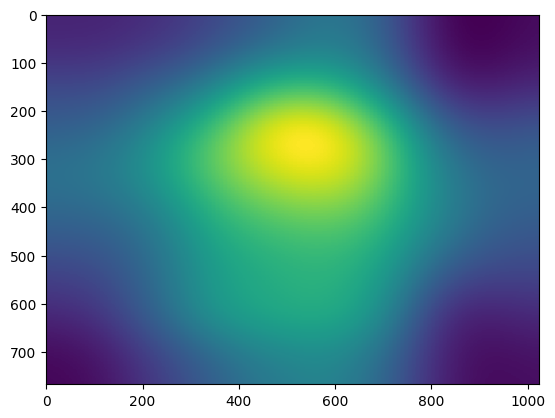

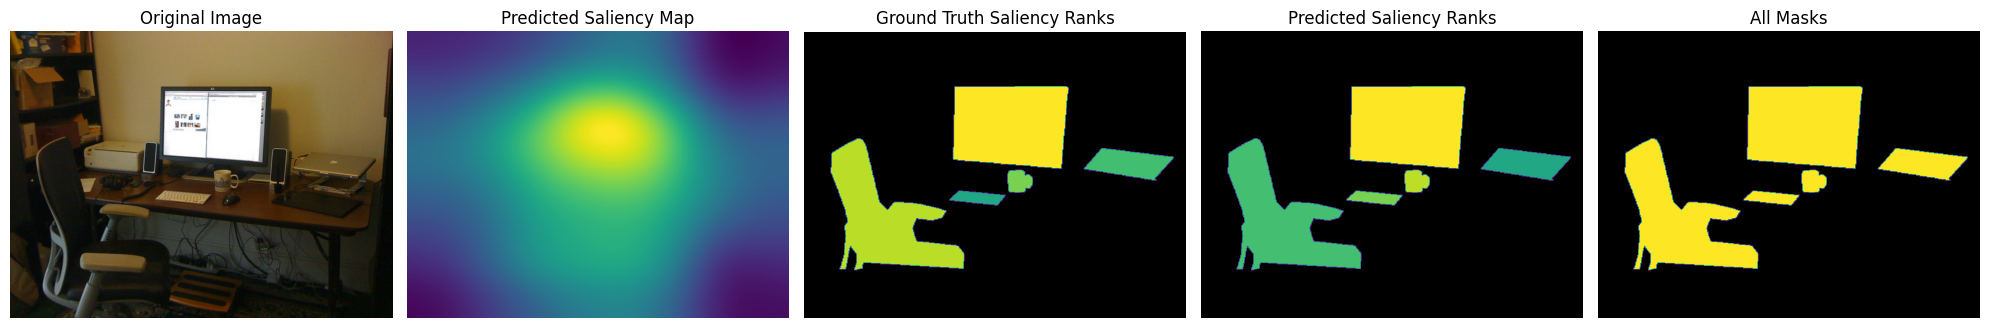

SOR: 0.8571428571428572


In [82]:
torch.cuda.empty_cache()

selected_entry = random.choice(test_data)
image_path = selected_entry['image']
mask_path = selected_entry['annotation']
image, mask = read_image(image_path, mask_path)

masks = []
msk_unique = np.unique(mask)
for i in range(1, len(msk_unique)):
    masks.append(mask == msk_unique[i])

saliency_map, pred_masks, segment_ranks, grayscale_image = saliency_rank_predictor.predict(image, masks)

all_masks = np.zeros_like(mask)
for i, tmp_mask in enumerate(pred_masks):
    all_masks += tmp_mask

plt.figure(figsize=(20, 10))
plt.subplot(1, 5, 1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(saliency_map, cmap='viridis')
plt.title('Predicted Saliency Map')
plt.axis('off')

plt.subplot(1, 5, 3)
plt.imshow(mask, cmap=new_cmap)
plt.title('Ground Truth Saliency Ranks')
plt.axis('off')

plt.subplot(1, 5, 4)
plt.imshow(grayscale_image, cmap=new_cmap)
plt.title('Predicted Saliency Ranks')
plt.axis('off')

plt.subplot(1, 5, 5)
plt.imshow(all_masks, cmap=new_cmap)
plt.title('All Masks')
plt.axis('off')

plt.tight_layout()

plt.show()

# print(f'MAE: {new_sor((grayscale_image * 255).astype(np.uint8), mask)}')
print(f'SOR: {new_sor((grayscale_image * 255).astype(np.uint8), mask)}')


In [77]:
def new_sor(pred, gt):
    def iou(pred, gt):
        intersection = np.sum(pred & gt)
        union = np.sum(pred | gt)
        return intersection / union

    pred_unique = np.unique(pred).astype(int)
    gt_unique = np.unique(gt).astype(int)

    pred_objects = {}
    gt_objects = {}

    for val in pred_unique:
        pred_objects[val] = {}
        pred_objects[val]['mask'] = pred == val
        pred_objects[val]['saliency'] = np.mean(pred == val)

    for val in gt_unique:
        gt_objects[val] = {}
        gt_objects[val]['mask'] = gt == val
        gt_objects[val]['saliency'] = np.mean(gt == val)

    # List of keys sorted by their saliency
    pred_keys_sorted = sorted(pred_objects, key=lambda x: pred_objects[x]['saliency'], reverse=True)
    gt_keys_sorted = sorted(gt_objects, key=lambda x: gt_objects[x]['saliency'], reverse=True)

    sprc = spearmanr(pred_keys_sorted, gt_keys_sorted).correlation

    # Normalise to range [0, 1]
    sprc = (sprc + 1) / 2

    return sprc


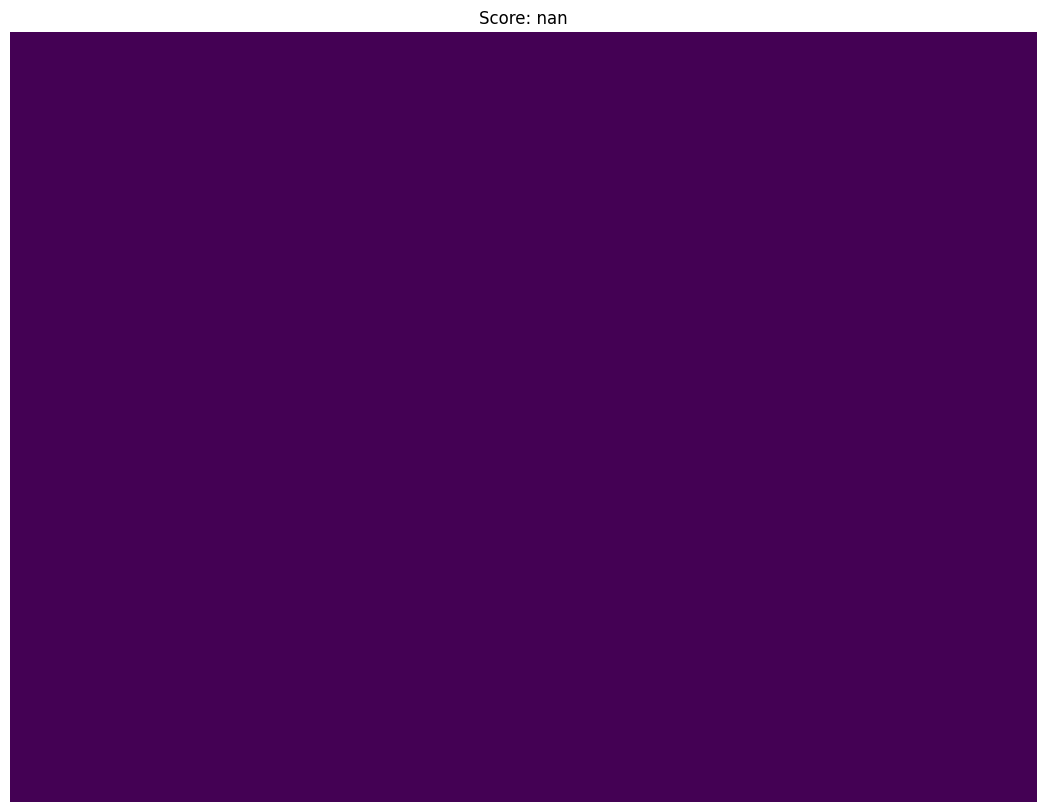

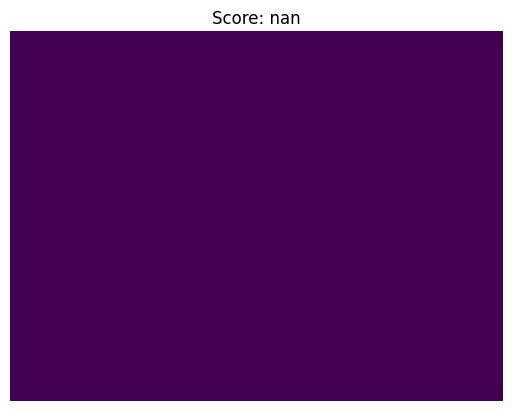

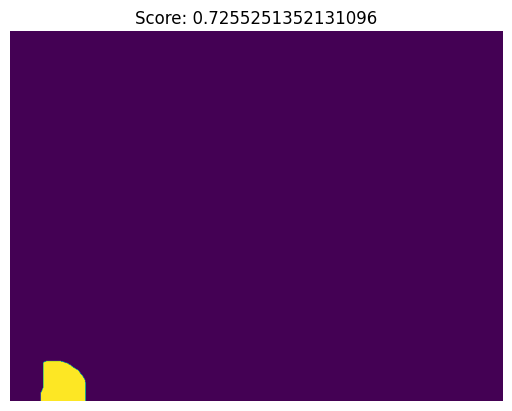

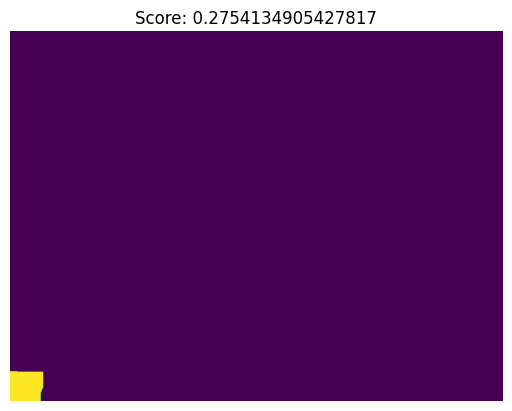

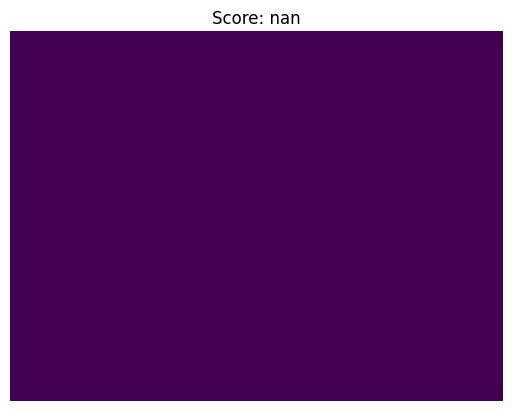

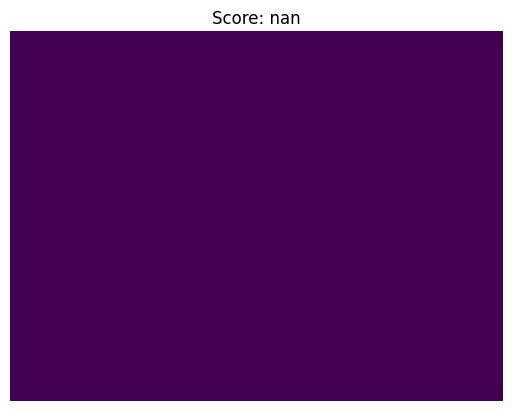

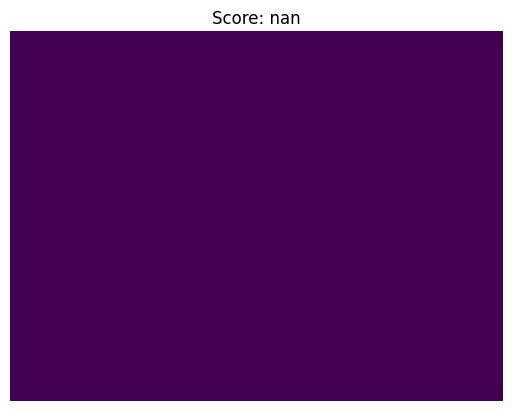

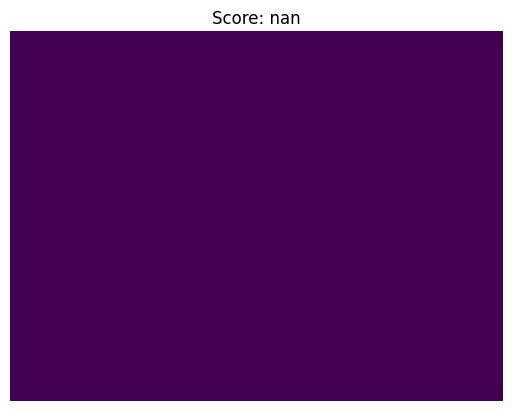

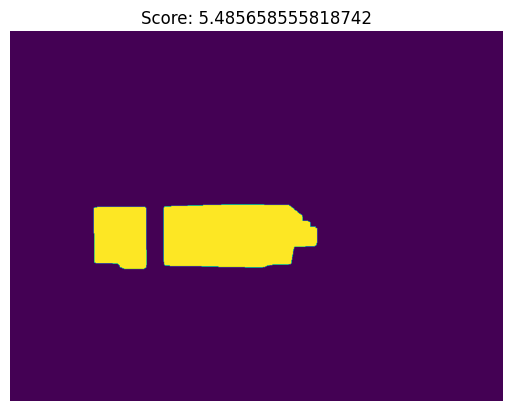

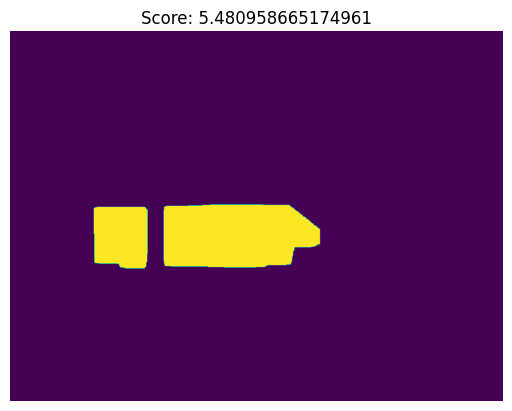

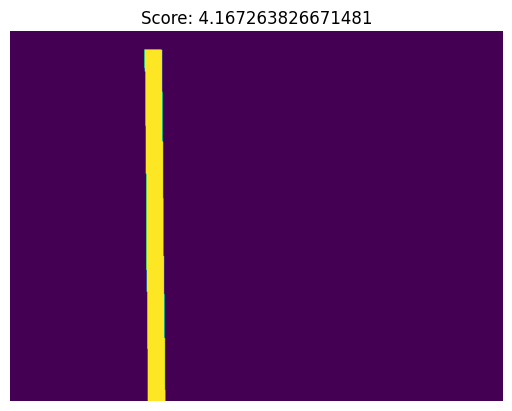

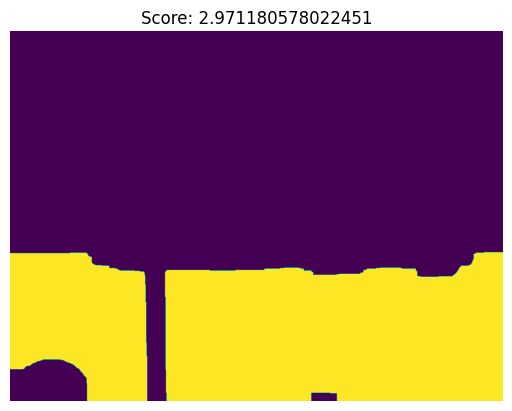

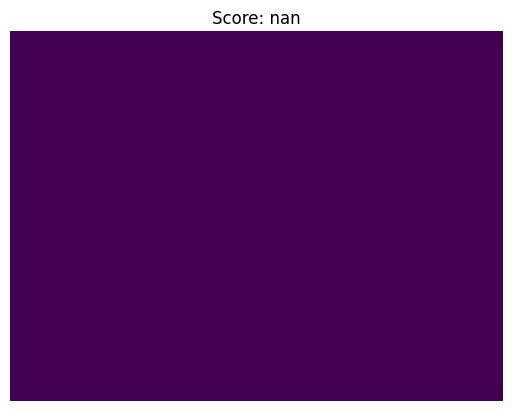

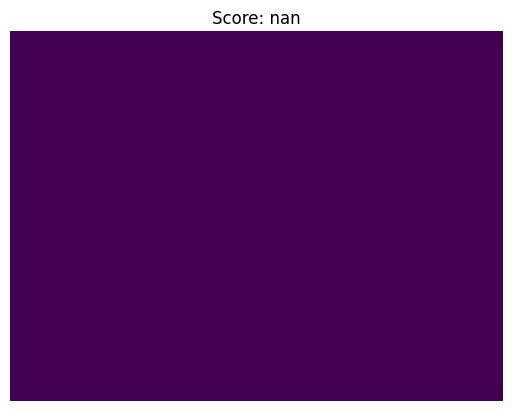

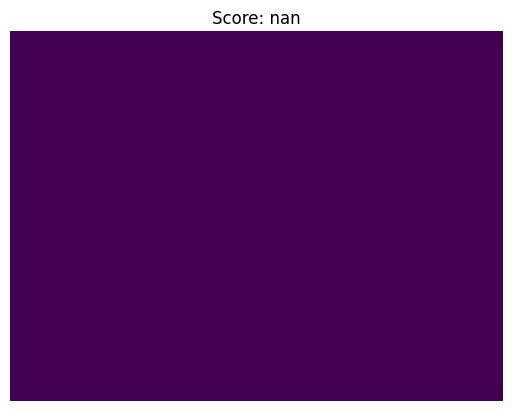

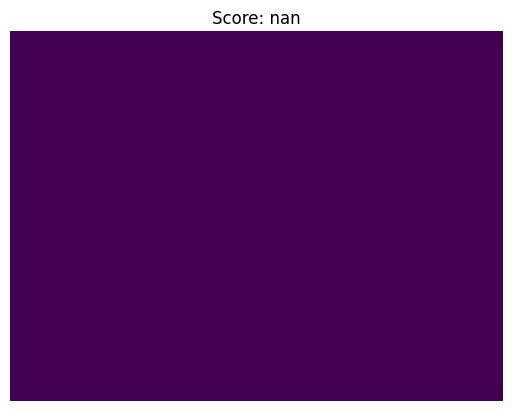

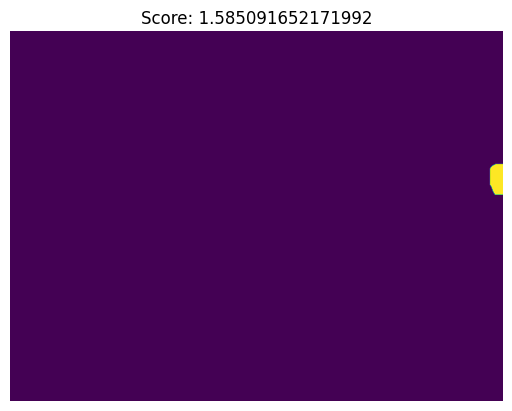

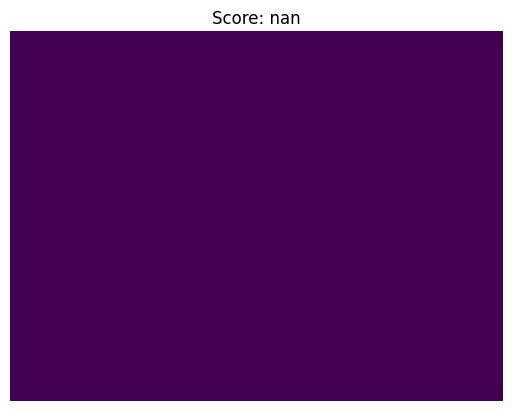

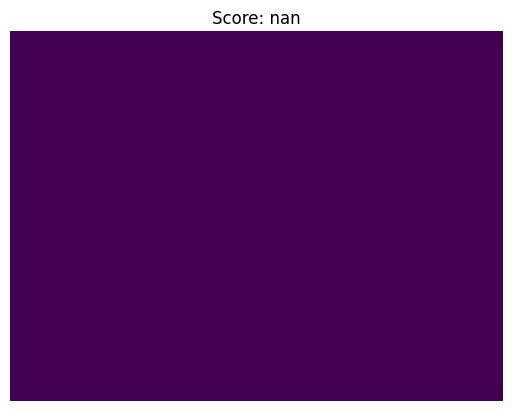

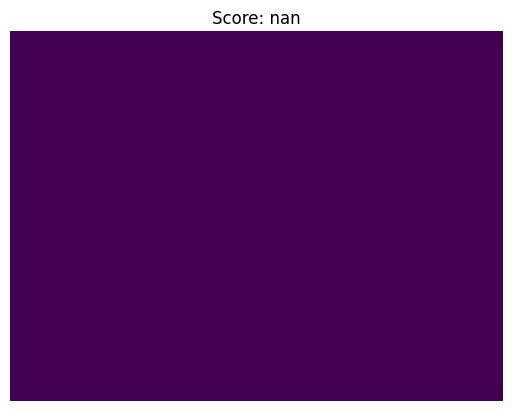

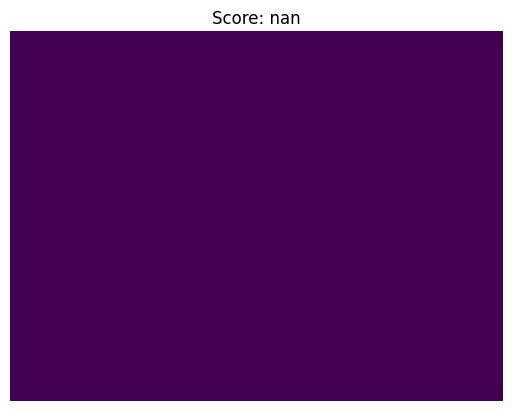

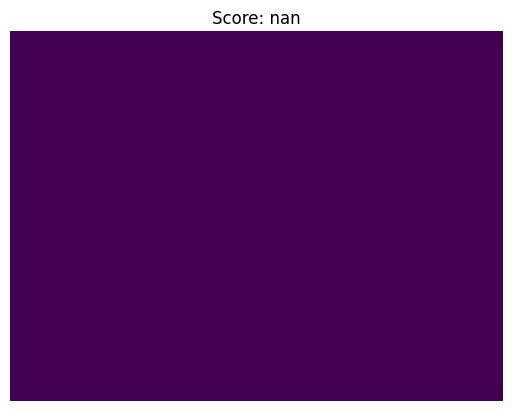

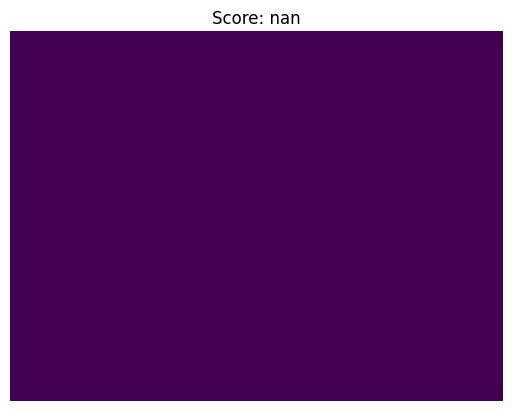

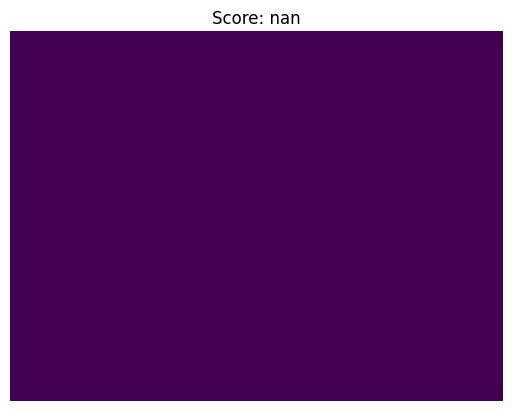

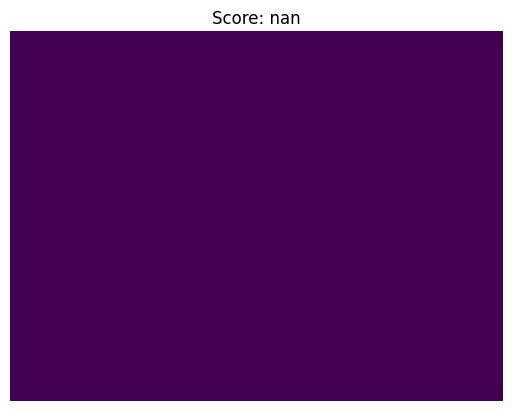

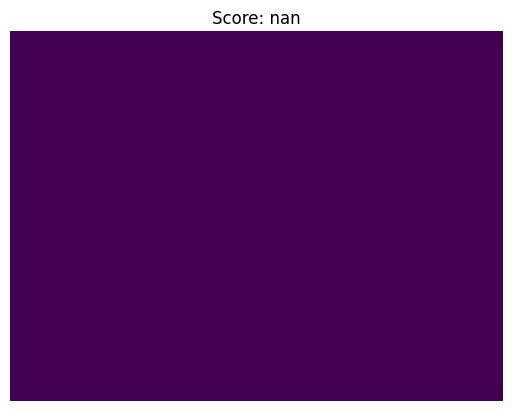

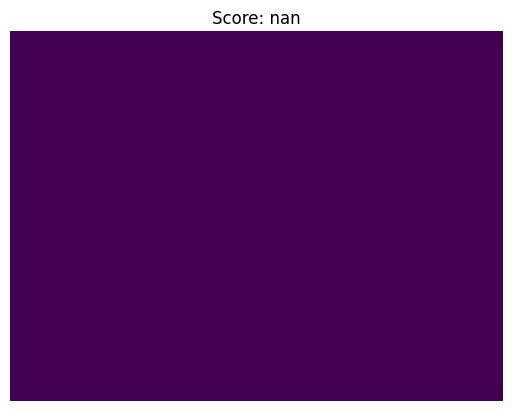

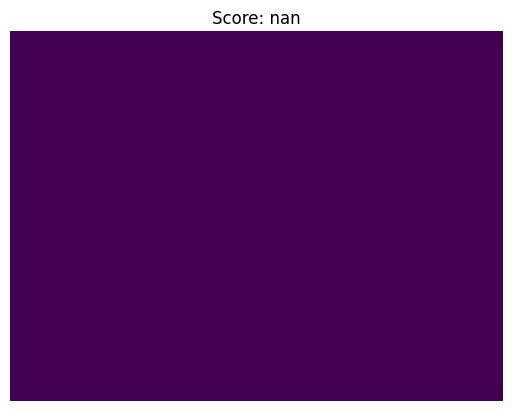

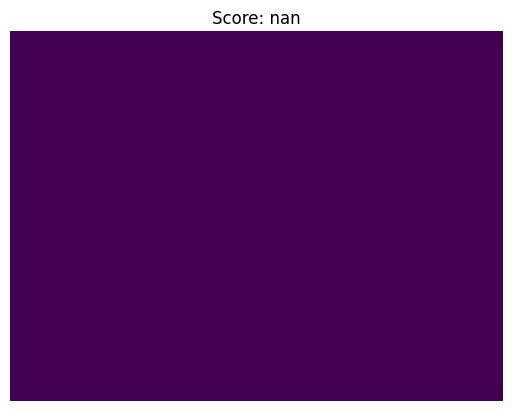

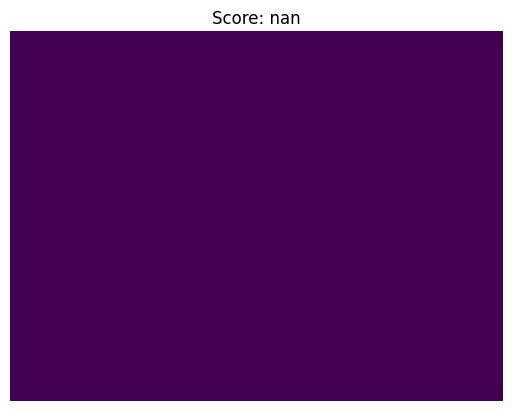

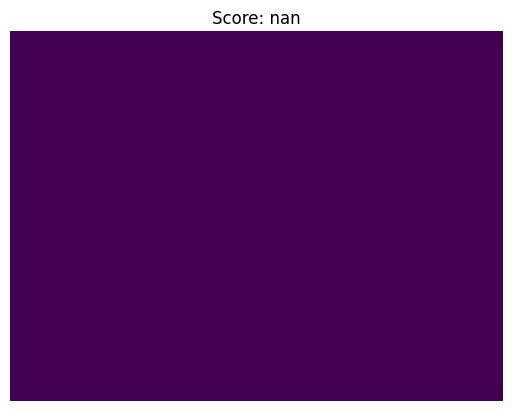

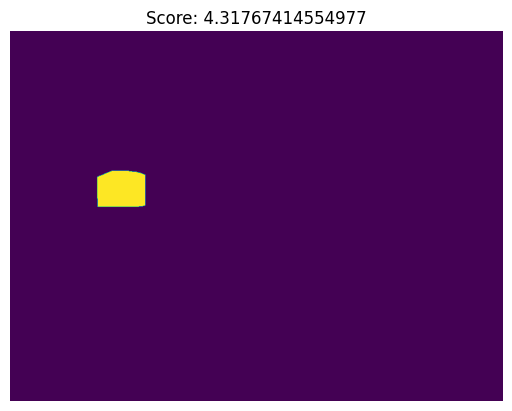

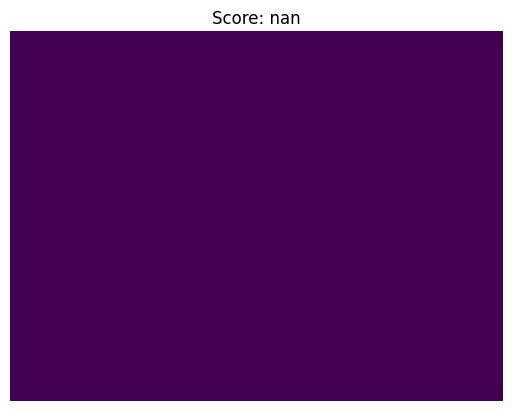

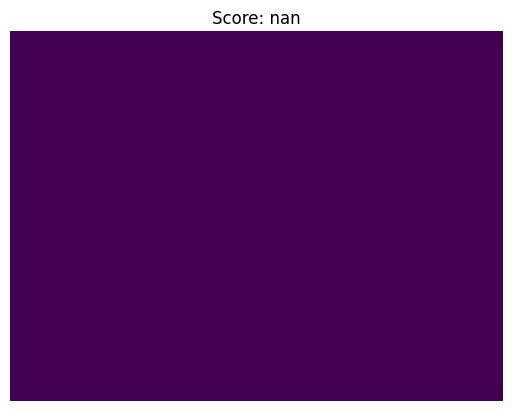

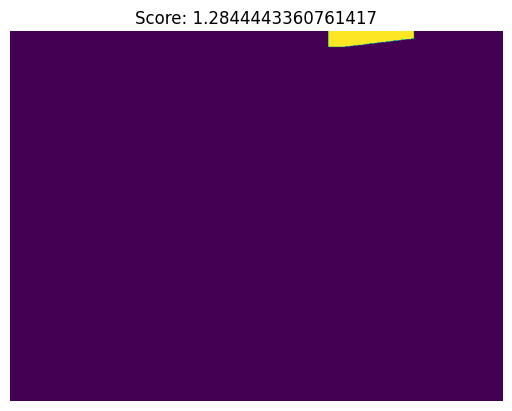

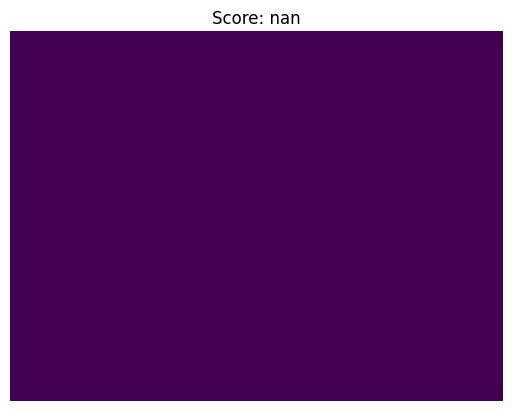

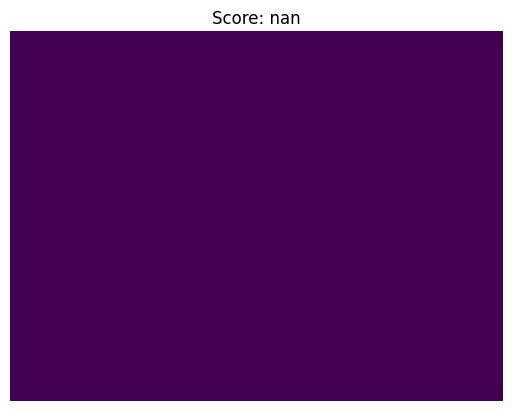

In [95]:
plt.figure(figsize=(20, 10))

for segment in segment_ranks:
    mask = segment[1]['mask']
    score = segment[1]['score']
    plt.imshow(mask, cmap='viridis')
    plt.title(f'Score: {score}')
    plt.axis('off')
    plt.show()

  1%|          | 16/2418 [00:36<1:30:16,  2.26s/it]


KeyboardInterrupt: 

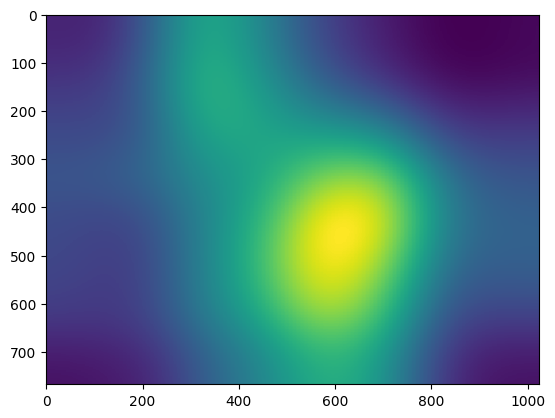

In [88]:
# Calculate MAE
maes = []

# Calculate SOR
sors = []

# selected_entry = random.choice(test_data)
# image_path = selected_entry['image']
# mask_path = selected_entry['annotation']
# image, mask = read_image(image_path, mask_path)

for entry in tqdm(test_data):
    image_path = entry['image']
    mask_path = entry['annotation']
    image, mask = read_image(image_path, mask_path)

    masks = []
    msk_unique = np.unique(mask)
    for i in range(1, len(msk_unique)):
        masks.append(mask == msk_unique[i])

    # image = image.squeeze(0).permute(1, 2, 0).numpy()
    # mask = mask.squeeze(0).permute(1, 2, 0).numpy()

    _, _, _, grayscale_image = saliency_rank_predictor.predict(image, masks)

    pred = (grayscale_image * 255).astype(np.uint8)
    gt = mask

    # Calculate MAE
    mae = calculate_mae(pred, gt)
    maes.append(mae)

    # Calculate SOR
    sor = new_sor(pred, gt)
    # if sor is not None:
    sors.append(sor)
    

    # plt.figure(figsize=(10, 5))
    # plt.subplot(1, 3, 1)
    # plt.imshow(image, cmap='gray')
    # plt.title(f'Image')
    # plt.axis('off')

    # plt.subplot(1, 3, 2)
    # plt.imshow(pred, cmap=new_cmap)
    # plt.title(f'Prediction, MAE: {mae:.4f}, SOR: {sor:.4f}')
    # plt.axis('off')

    # plt.subplot(1, 3, 3)
    # plt.imshow(gt, cmap=new_cmap)
    # plt.title('Ground Truth')
    # plt.axis('off')

    # plt.show()

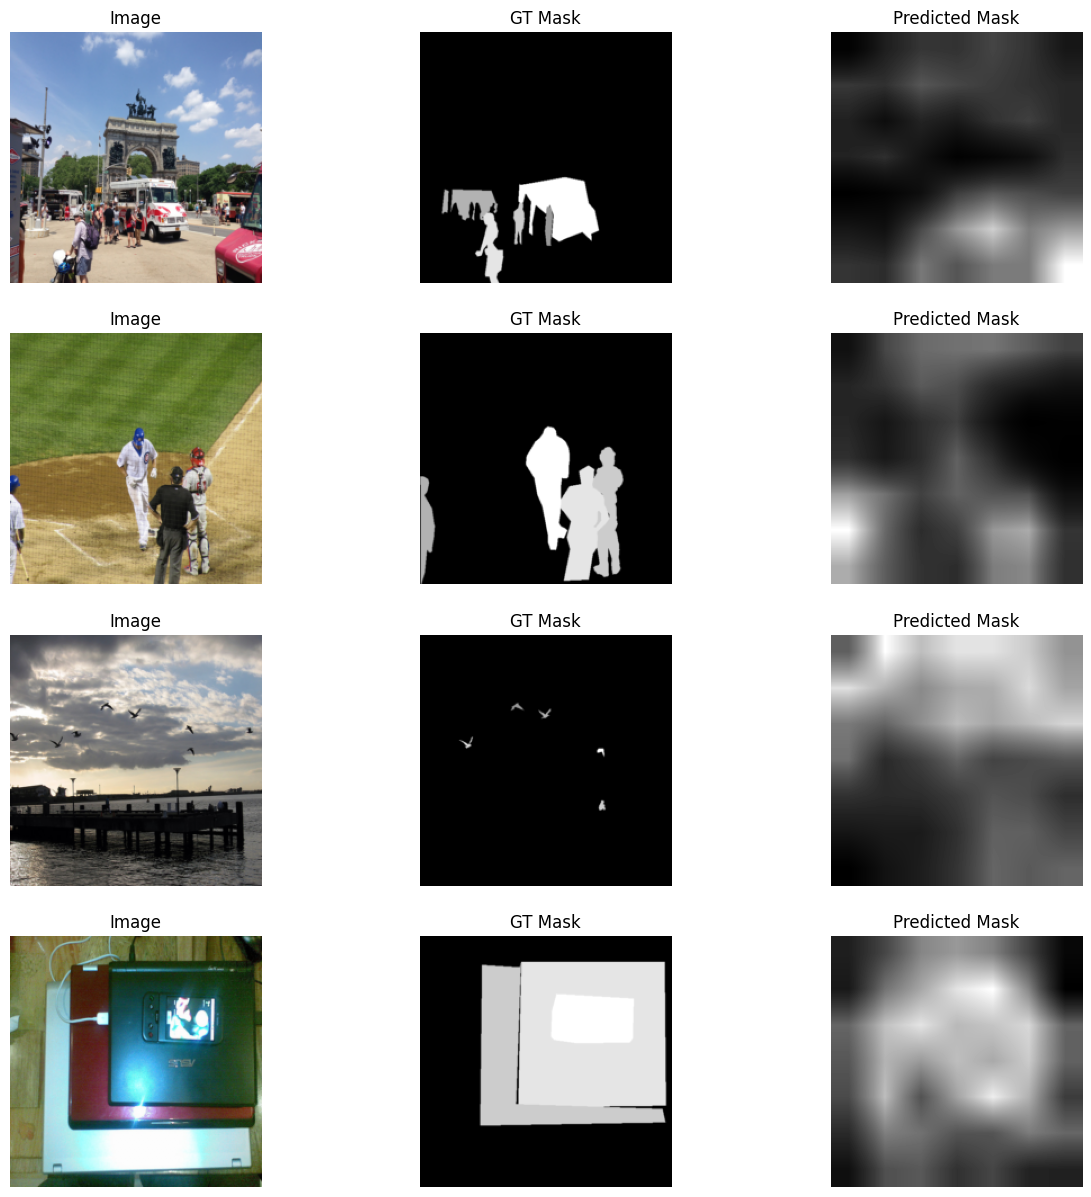

In [33]:
# Qaulitative results. Load some test examples and their GT. Input test into model and display the results
subset_indices = list(range(4))
test_loader = DataLoader(test_dataset, batch_size=1, sampler=torch.utils.data.SubsetRandomSampler(subset_indices))

model.eval()  # Set model to evaluation mode

images = []
gt_masks = []
pred_masks = []

for image, mask in test_loader:
    images.append(image.squeeze().numpy())
    gt_masks.append(mask.squeeze().numpy())

    with torch.no_grad():
        output = model(image.to('cuda' if torch.cuda.is_available() else 'cpu'))
    
    pred_masks.append(output.squeeze().cpu().numpy())

images = np.array(images)
gt_masks = np.array(gt_masks)
pred_masks = np.array(pred_masks)

# Display the images, GT masks, and predicted masks
plt.figure(figsize=(15, 15))
for i in range(4):
    plt.subplot(4, 3, i*3 + 1)
    plt.imshow(images[i].transpose(1, 2, 0))
    plt.axis('off')
    plt.title('Image')

    plt.subplot(4, 3, i*3 + 2)
    plt.imshow(gt_masks[i], cmap='gray')
    plt.axis('off')
    plt.title('GT Mask')

    plt.subplot(4, 3, i*3 + 3)
    plt.imshow(pred_masks[i], cmap='gray')
    plt.axis('off')
    plt.title('Predicted Mask')